# 01 - Data Understanding, Cleaning, Missing Values, Preprocessing, ICD-9 Grouping, EDA

## 0. Problem Definition and Unit of Observation
Unit of observation (sample): 1 row = 1 hospital encounter (encounter_id), NOT 1 patient. A patient (patient_nbr) may have multiple hospital encounters → the data should be split by patient_nbr to prevent data leakage (see Section 3).

Problem: Binary classification. The target = 1 if the patient is readmitted within <30 days, and = 0 if the patient is readmitted after >30 days or is not readmitted.

Input: Features related to demographics, treatment processes, diagnoses (diag_1/2/3), and diabetes medications.

Output: target (0/1), with an imbalanced dataset (~11% positive).

In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from preprocessing import (
    load_raw_data, basic_clean, create_target, group_unknown_ids,
    add_diag_groups, split_train_test, fit_near_constant_cols, drop_cols,
    handle_missing_values, fit_categories, apply_categories,
)

OUTPUT_FIG_DIR = "../outputs/figures"

## 1. Data understanding

In [2]:
df_raw, ids_mapping = load_raw_data("../input")
print(df_raw.shape)
df_raw.info()
df_raw.describe()
df_raw.describe(include='object')

(101766, 50)
<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications   

C:\Users\Admin\AppData\Local\Temp\ipykernel_24220\2069337384.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_raw.describe(include='object')


,race,gender,age,weight,payer_code,medical_specialty,diag_1,diag_2,diag_3,max_glu_serum,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
count,101766,101766,101766,101766,101766,101766,101766,101766,101766,5346,...,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766
unique,6,3,10,10,18,73,717,749,790,3,...,1,4,4,2,2,2,2,2,2,3
top,Caucasian,Female,[70-80),?,?,?,428,276,250,Norm,...,No,No,No,No,No,No,No,No,Yes,NO
freq,76099,54708,26068,98569,40256,49949,6862,6752,11555,2597,...,101766,47383,101060,101753,101765,101764,101765,54755,78363,54864


In [3]:
#Check the proportion of '?' in each column (before change to NaN)
missing_mark_pct = (df_raw == '?').mean().sort_values(ascending=False)
missing_mark_pct[missing_mark_pct > 0]

weight               0.968585
medical_specialty    0.490822
payer_code           0.395574
race                 0.022336
diag_3               0.013983
diag_2               0.003518
diag_1               0.000206
dtype: float64

In [4]:
df_raw['readmitted'].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

## 2. Cleaning (rule-based) + target creation + ICD-9 grouping

In [5]:
df_step1 = basic_clean(df_raw)
df_step1 = create_target(df_step1)
df_step1 = group_unknown_ids(df_step1)
df_step1 = add_diag_groups(df_step1)
df_step1.shape

[basic_clean] Removed 2423 rows (expired/hospice). 99343 rows remaining.


(99343, 53)

## 3. Split train/test set by patient_nbr

In [6]:
train_df, test_df = split_train_test(df_step1)

[split_train_test] Train: 79541 rows / Test: 19802 rows
[split_train_test] Target rate - train: 0.1144, test: 0.1119  (GroupShuffleSplit does not support true stratification when grouping by patient_nbr, so the target rate is checked after splitting; if the difference is substantial, consider StratifiedGroupKFold in sklearn >=1.0)


In [7]:
from scipy.stats import chi2_contingency

for col in ["medical_specialty", "payer_code", "race"]:
    ct = pd.crosstab(train_df[col].isna(), train_df["target"])
    chi2, p, dof, exp = chi2_contingency(ct)
    ket_luan = "Associated with target" if p < 0.05 else "No clear association found"
    print(f"{col}: ty le thieu = {train_df[col].isna().mean():.2%}, "
          f"chi-square p-value = {p:.4g} ({ket_luan})")

medical_specialty: ty le thieu = 48.92%, chi-square p-value = 1.981e-05 (Associated with target)
payer_code: ty le thieu = 39.68%, chi-square p-value = 0.0738 (No clear association found)
race: ty le thieu = 2.28%, chi-square p-value = 1.976e-05 (Associated with target)


## 4. Steps Fitted on Train and Applied to Test

### 4.1. Drop Near-Constant Columns (Fitted on Train)

In [8]:
dropped_cols = fit_near_constant_cols(train_df)
train_df = drop_cols(train_df, dropped_cols)
test_df = drop_cols(test_df, dropped_cols)
train_df.shape, test_df.shape

[fit_near_constant_cols] Columns to drop (fitted on train): ['examide', 'citoglipton', 'acetohexamide', 'troglitazone', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']


((79541, 46), (19802, 46))

### 4.2 Missing values

In [9]:
train_df = handle_missing_values(train_df)
test_df = handle_missing_values(test_df)

[handle_missing_values] Columns with remaining NaN values:
diag_1      15
diag_2     296
diag_3    1169
dtype: int64
[handle_missing_values] Columns with remaining NaN values:
diag_1      5
diag_2     60
diag_3    250
dtype: int64


### 4.3 Categorical Data Types (Categories Fitted on Train)

In [10]:
categories = fit_categories(train_df)
train_df = apply_categories(train_df, categories)
test_df = apply_categories(test_df, categories)
train_df.dtypes

encounter_id                   int64
patient_nbr                    int64
race                        category
gender                      category
age                         category
admission_type_id           category
discharge_disposition_id    category
admission_source_id         category
time_in_hospital               int64
payer_code                  category
medical_specialty           category
num_lab_procedures             int64
num_procedures                 int64
num_medications                int64
number_outpatient              int64
number_emergency               int64
number_inpatient               int64
diag_1                           str
diag_2                           str
diag_3                           str
number_diagnoses               int64
max_glu_serum               category
A1Cresult                   category
metformin                        str
repaglinide                      str
nateglinide                      str
chlorpropamide                   str
g

### 4.4 Outlier Treatment (Fitted on Train)

In [11]:
from preprocessing import fit_outlier_caps, apply_outlier_caps

outlier_caps = fit_outlier_caps(train_df)
train_df = apply_outlier_caps(train_df, outlier_caps)
test_df = apply_outlier_caps(test_df, outlier_caps)

[fit_outlier_caps] Capping thresholds (fitted on train): {'num_medications': (np.int64(1), 35.0), 'num_lab_procedures': (np.int64(1), 96.0), 'number_diagnoses': (1.5, 13.5)}
[apply_outlier_caps] num_medications: capped 1973 rows outside [1.0, 35.0]
[apply_outlier_caps] num_lab_procedures: capped 87 rows outside [1.0, 96.0]
[apply_outlier_caps] number_diagnoses: capped 229 rows outside [1.5, 13.5]
[apply_outlier_caps] num_medications: capped 482 rows outside [1.0, 35.0]
[apply_outlier_caps] num_lab_procedures: capped 33 rows outside [1.0, 96.0]
[apply_outlier_caps] number_diagnoses: capped 48 rows outside [1.5, 13.5]


## 5. Post-Split Checks (Target Balance and No Patient Overlap)

In [12]:
print('Target - train rate:', train_df['target'].mean())
print('Target - test rate:', test_df['target'].mean())
trung_benh_nhan = set(train_df['patient_nbr']) & set(test_df['patient_nbr'])
print('Number of patients overlapping between train/test (should be 0):', len(trung_benh_nhan))

Target - train rate: 0.11438126249355678
Target - test rate: 0.11190788809211191
Number of patients overlapping between train/test (should be 0): 0


In [13]:
train_df = train_df.drop(columns=["patient_nbr", "encounter_id"])
test_df = test_df.drop(columns=["patient_nbr", "encounter_id"])

## 6. EDA

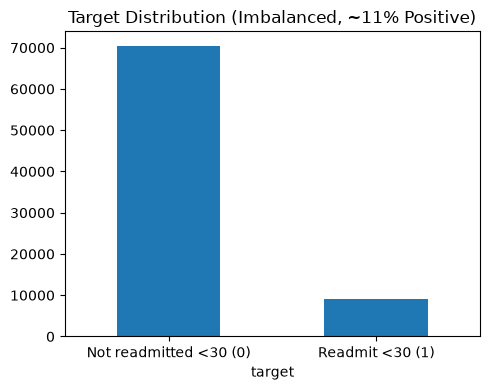

In [14]:
fig, ax = plt.subplots(figsize=(5, 4))
train_df['target'].value_counts().sort_index().plot(kind='bar', ax=ax)
ax.set_xticklabels(['Not readmitted <30 (0)', 'Readmit <30 (1)'], rotation=0)
ax.set_title('Target Distribution (Imbalanced, ~11% Positive)')
plt.tight_layout()
plt.savefig(f"{OUTPUT_FIG_DIR}/target_distribution.png", dpi=150)
plt.show()

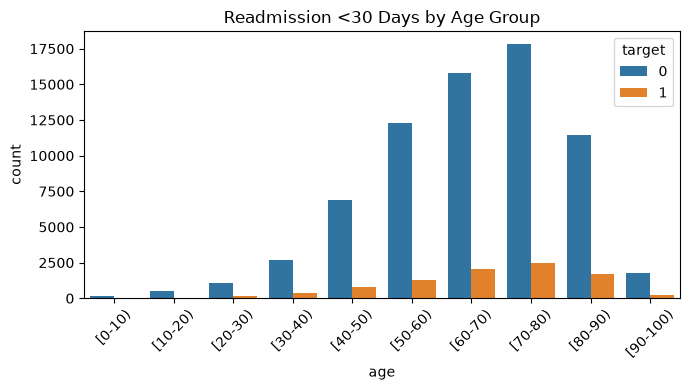

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=train_df, x='age', hue='target', ax=ax,
              order=sorted(train_df['age'].unique()))
ax.set_title('Readmission <30 Days by Age Group')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{OUTPUT_FIG_DIR}/age_vs_target.png", dpi=150)
plt.show()

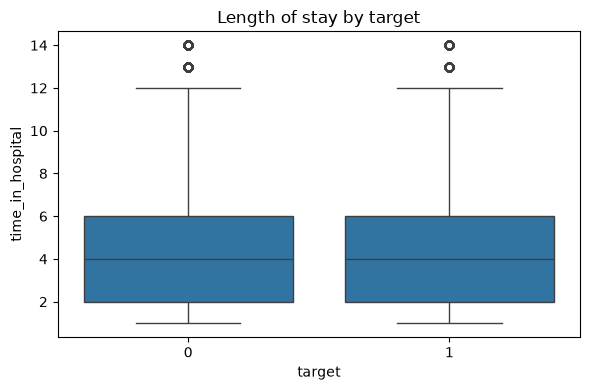

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=train_df, x='target', y='time_in_hospital', ax=ax)
ax.set_title('Length of stay by target')
plt.tight_layout()
plt.savefig(f"{OUTPUT_FIG_DIR}/time_in_hospital_vs_target.png", dpi=150)
plt.show()

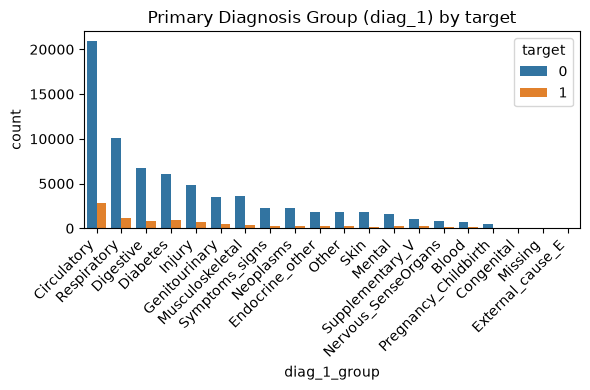

In [17]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=train_df, x='diag_1_group', hue='target', ax=ax,
              order=train_df['diag_1_group'].value_counts().index)
ax.set_title('Primary Diagnosis Group (diag_1) by target')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f"{OUTPUT_FIG_DIR}/diag1_group_vs_target.png", dpi=150)
plt.show()

number_inpatient      0.168906
number_emergency      0.059015
number_diagnoses      0.053881
time_in_hospital      0.046483
num_medications       0.043745
num_lab_procedures    0.024952
number_outpatient     0.020348
num_procedures       -0.014765
Name: target, dtype: float64


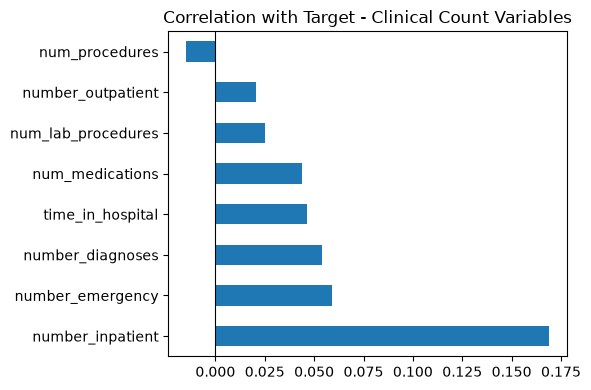

In [18]:
# --- Clinical count variables vs target ---
num_cols = [
    "number_inpatient", "number_emergency", "number_outpatient",
    "num_medications", "num_lab_procedures", "num_procedures",
    "time_in_hospital", "number_diagnoses",
]
corr_target = (
    train_df[num_cols + ["target"]].corr()["target"].drop("target")
    .sort_values(key=abs, ascending=False)
)
print(corr_target)

fig, ax = plt.subplots(figsize=(6, 4))
corr_target.plot(kind="barh", ax=ax)
ax.set_title("Correlation with Target - Clinical Count Variables")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig(f"{OUTPUT_FIG_DIR}/numeric_corr_with_target.png", dpi=150)
plt.show()

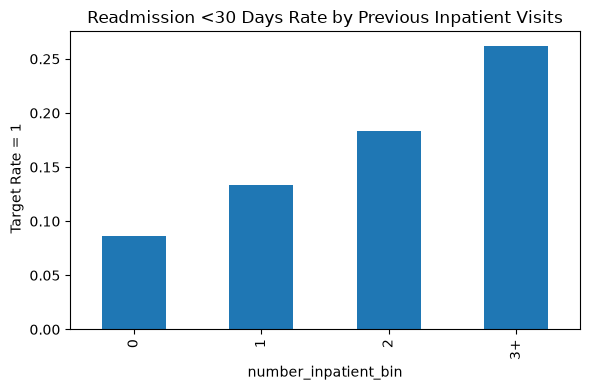

In [19]:
# --- Number_inpatient by bin (strongest feature) ---
fig, ax = plt.subplots(figsize=(6, 4))
bins = [0, 1, 2, 3, train_df["number_inpatient"].max() + 1]
labels = ["0", "1", "2", "3+"]
train_df["number_inpatient_bin"] = pd.cut(
    train_df["number_inpatient"], bins=bins, labels=labels,
    right=False, include_lowest=True
)
rate_by_bin = train_df.groupby("number_inpatient_bin", observed=True)["target"].mean()
rate_by_bin.plot(kind="bar", ax=ax)
ax.set_title("Readmission <30 Days Rate by Previous Inpatient Visits")
ax.set_ylabel(" Target Rate = 1")
plt.tight_layout()
plt.savefig(f"{OUTPUT_FIG_DIR}/number_inpatient_vs_target.png", dpi=150)
plt.show()
# Remove the temporary column after plotting; not save it to the file
train_df = train_df.drop(columns=["number_inpatient_bin"])

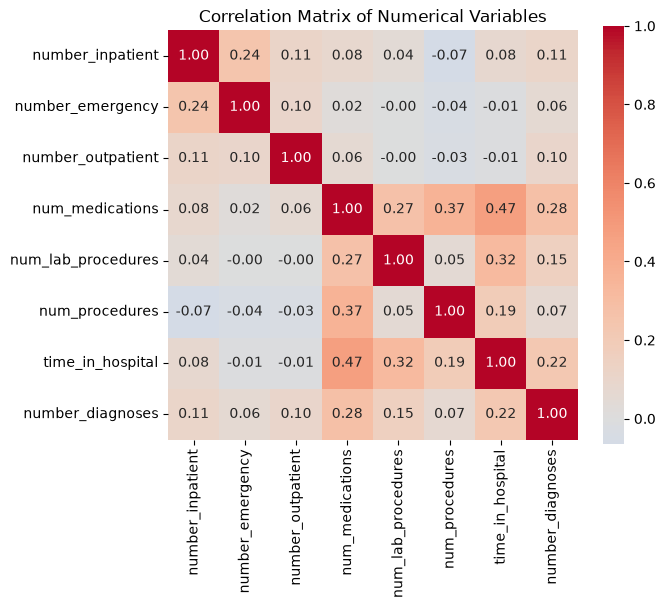

In [20]:
# --- Correlation matrix among numerical variables ---
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(train_df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, square=True)
ax.set_title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.savefig(f"{OUTPUT_FIG_DIR}/numeric_corr_heatmap.png", dpi=150)
plt.show()

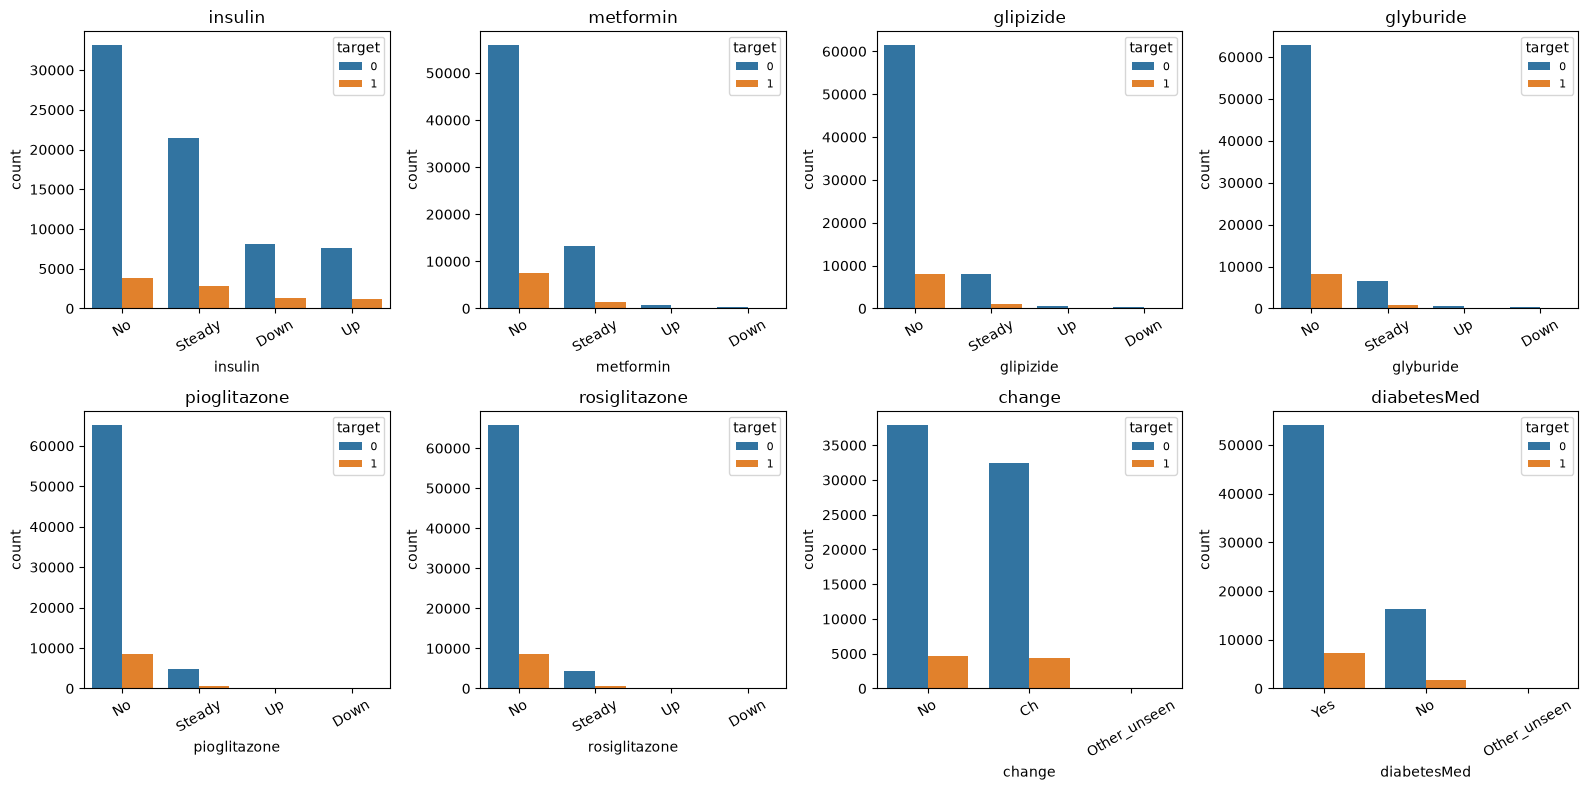

In [21]:
# --- Diabetes medications vs target ---
med_cols = ["insulin", "metformin", "glipizide", "glyburide",
            "pioglitazone", "rosiglitazone", "change", "diabetesMed"]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flatten(), med_cols):
    order = train_df[col].value_counts().index
    sns.countplot(data=train_df, x=col, hue="target", ax=ax, order=order)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=30)
    ax.legend(title="target", fontsize=8)
plt.tight_layout()
plt.savefig(f"{OUTPUT_FIG_DIR}/medication_cols_vs_target.png", dpi=150)
plt.show()

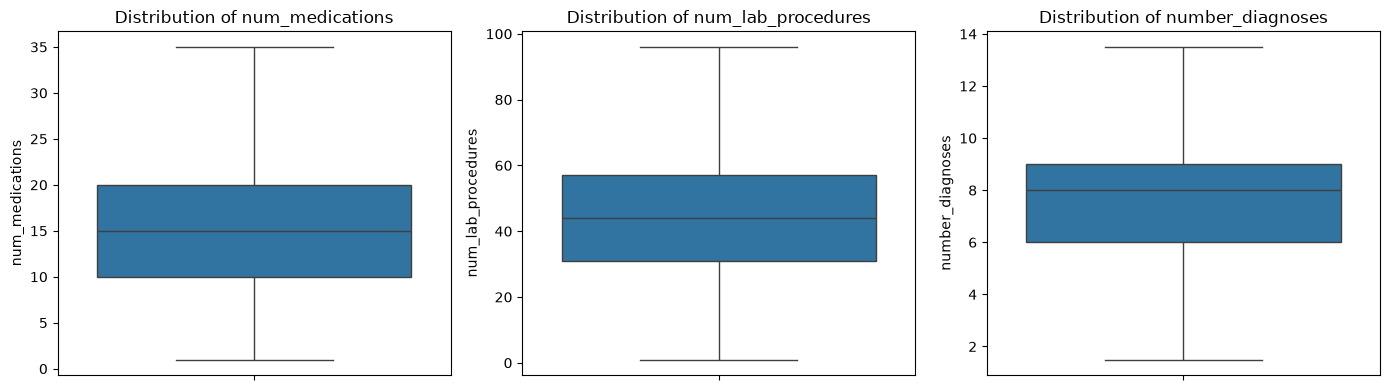

       num_medications  num_lab_procedures  number_diagnoses
count     79541.000000        79541.000000      79541.000000
mean         15.769653           42.917024          7.398618
std           7.374406           19.554227          1.936808
min           1.000000            1.000000          1.500000
25%          10.000000           31.000000          6.000000
50%          15.000000           44.000000          8.000000
75%          20.000000           57.000000          9.000000
max          35.000000           96.000000         13.500000


In [22]:
# --- Outliers / distributions of key numerical variables ---
# Note: Outliers were capped in Section 4.4 (thresholds calculated on the
# train set), so the boxplots below show the data AFTER treatment and no
# longer contain extremely high values as in the original data.
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["num_medications", "num_lab_procedures", "number_diagnoses"]):
    sns.boxplot(data=train_df, y=col, ax=ax)
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.savefig(f"{OUTPUT_FIG_DIR}/outliers_numeric_cols.png", dpi=150)
plt.show()

print(train_df[["num_medications", "num_lab_procedures",
                 "number_diagnoses"]].describe())

In [23]:
# --- Association Between Categorical Variables and Target (Cramer's V) ---
from scipy.stats import chi2_contingency

def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return (chi2 / (n * (min(r, k) - 1))) ** 0.5

cat_cols_to_check = [
    "race", "gender", "age", "admission_type_id",
    "discharge_disposition_id", "admission_source_id",
    "diag_1_group", "diag_2_group", "diag_3_group",
    "insulin", "change", "diabetesMed", "A1Cresult", "max_glu_serum",
]

results = []
for col in cat_cols_to_check:
    if col in train_df.columns:
        ct = pd.crosstab(train_df[col], train_df["target"])
        v = cramers_v(ct)
        chi2, p, _, _ = chi2_contingency(ct)
        results.append({"column": col, "cramers_v": v, "p_value": p})

cat_assoc_df = pd.DataFrame(results).sort_values("cramers_v", ascending=False)
cat_assoc_df

,column,cramers_v,p_value
4,discharge_disposition_id,0.112332,8.657883e-201
8,diag_3_group,0.044049,3.180541e-23
9,insulin,0.043395,2.928568e-32
6,diag_1_group,0.040145,3.205707e-18
2,age,0.038690,2.074287e-21
7,diag_2_group,0.037305,5.943767e-15
5,admission_source_id,0.024804,9.192013e-06
11,diabetesMed,0.024642,3.662027e-12
12,A1Cresult,0.022112,1.832172e-08
3,admission_type_id,0.018464,5.411959e-05


## 7. Save Processed Files

In [24]:
train_df.to_csv("../data/train_clean.csv", index=False)
test_df.to_csv("../data/test_clean.csv", index=False)
print("Saved data/train_clean.csv and data/test_clean.csv")

Saved data/train_clean.csv and data/test_clean.csv
